# Final Paper Notebook


## 0. Path Setup

In [1]:
import sys

PROJECT_SRC = "/Users/patriziavincenzi/Downloads/project/src"

if PROJECT_SRC not in sys.path:
    sys.path.append(PROJECT_SRC)

## 1. Write Core Project Files

In [2]:
%%writefile /Users/patriziavincenzi/Downloads/project/src/data.py
from __future__ import annotations

import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml, make_classification
from sklearn.model_selection import train_test_split

MEDIUM_TRAIN_SIZE = 10_000
MIN_UNIQUE_NUMERICAL = 10
MAX_MISSING_FRACTION = 0.5


def load_openml_classification(name: str = "MagicTelescope", version: int = 1):
    bunch = fetch_openml(name=name, version=version, as_frame=True)
    return bunch.data.copy(), bunch.target.copy()


def make_synthetic_classification(n_samples: int = 12_000, seed: int = 0):
    rng = np.random.default_rng(seed)

    X_array, y_array = make_classification(
        n_samples=n_samples,
        n_features=12,
        n_informative=6,
        n_redundant=3,
        n_classes=3,
        n_clusters_per_class=2,
        weights=[0.5, 0.3, 0.2],
        random_state=seed,
    )

    X = pd.DataFrame(X_array, columns=[f"num_{i}" for i in range(X_array.shape[1])])
    X["low_card_num"] = rng.integers(0, 5, size=n_samples).astype(float)

    for col in ["num_0", "num_1"]:
        mask = rng.random(n_samples) < 0.02
        X.loc[mask, col] = np.nan

    y = pd.Series(y_array, name="target").astype("category")
    return X, y


def keep_numerical_only(X: pd.DataFrame) -> pd.DataFrame:
    return X.select_dtypes(include="number").copy()


def drop_missing(X: pd.DataFrame, y: pd.Series):
    keep_cols = X.columns[X.isna().mean() <= MAX_MISSING_FRACTION]
    X = X[keep_cols]

    row_mask = X.notna().all(axis=1)
    X = X[row_mask].reset_index(drop=True)
    y = y[row_mask].reset_index(drop=True)

    return X, y


def drop_low_cardinality_numerical(X: pd.DataFrame) -> pd.DataFrame:
    keep_cols = [col for col in X.columns if X[col].nunique() >= MIN_UNIQUE_NUMERICAL]
    return X[keep_cols].copy()


def binarize_and_balance(X: pd.DataFrame, y: pd.Series, seed: int = 0):
    y = y.astype(str)

    counts = y.value_counts()
    top2 = list(counts.index[:2])

    mask = y.isin(top2)
    X = X[mask].reset_index(drop=True)
    y = y[mask].reset_index(drop=True)

    n_per_class = min((y == top2[0]).sum(), (y == top2[1]).sum())

    rng = np.random.default_rng(seed)
    keep_indices = []

    for cls in top2:
        cls_indices = np.where(y.values == cls)[0]
        sampled_indices = rng.choice(cls_indices, size=n_per_class, replace=False)
        keep_indices.extend(sampled_indices)

    keep_indices = np.sort(keep_indices)

    X = X.iloc[keep_indices].reset_index(drop=True)
    y = y.iloc[keep_indices].reset_index(drop=True)

    y = (y == top2[1]).astype(int)
    return X, y


def preprocess_numerical_classification(X: pd.DataFrame, y: pd.Series, seed: int = 0):
    X = keep_numerical_only(X)
    X, y = drop_missing(X, y)
    X = drop_low_cardinality_numerical(X)
    X, y = binarize_and_balance(X, y, seed=seed)

    return X, y


def split_and_truncate(X, y, test_size: float = 0.3, seed: int = 0):
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        stratify=y,
        random_state=seed,
    )

    if len(X_train) > MEDIUM_TRAIN_SIZE:
        X_train = X_train.iloc[:MEDIUM_TRAIN_SIZE]
        y_train = y_train.iloc[:MEDIUM_TRAIN_SIZE]

    return X_train, X_test, y_train, y_test


def split_train_val_test(
    X,
    y,
    test_size: float = 0.3,
    val_size: float = 0.2,
    seed: int = 0,
):
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        stratify=y,
        random_state=seed,
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val,
        y_train_val,
        test_size=val_size,
        stratify=y_train_val,
        random_state=seed,
    )

    if len(X_train) > MEDIUM_TRAIN_SIZE:
        X_train = X_train.iloc[:MEDIUM_TRAIN_SIZE]
        y_train = y_train.iloc[:MEDIUM_TRAIN_SIZE]

    return X_train, X_val, X_test, y_train, y_val, y_test

Overwriting /Users/patriziavincenzi/Downloads/project/src/data.py


In [3]:
%%writefile /Users/patriziavincenzi/Downloads/project/src/nn_models.py
from __future__ import annotations

import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.preprocessing import QuantileTransformer

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset

    TORCH_AVAILABLE = True
except Exception:
    TORCH_AVAILABLE = False


class MLP(nn.Module):
    def __init__(self, input_dim, n_layers=2, width=128, dropout=0.1):
        super().__init__()

        layers = []
        current_dim = input_dim

        for _ in range(n_layers):
            layers.append(nn.Linear(current_dim, width))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            current_dim = width

        layers.append(nn.Linear(current_dim, 1))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(1)


class ResNetBlock(nn.Module):
    def __init__(self, d, d_hidden, dropout):
        super().__init__()

        self.block = nn.Sequential(
            nn.Linear(d, d_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_hidden, d),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return x + self.block(x)


class ResNet(nn.Module):
    def __init__(self, input_dim, n_blocks=2, d=128, d_hidden=256, dropout=0.1):
        super().__init__()

        self.input_layer = nn.Linear(input_dim, d)
        self.blocks = nn.Sequential(
            *[ResNetBlock(d, d_hidden, dropout) for _ in range(n_blocks)]
        )
        self.output_layer = nn.Linear(d, 1)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.blocks(x)
        return self.output_layer(x).squeeze(1)


class TorchClassifier(BaseEstimator, ClassifierMixin):
    def __init__(
        self,
        module="mlp",
        seed=0,
        n_layers=2,
        width=128,
        n_blocks=2,
        d=128,
        d_hidden=256,
        dropout=0.1,
        learning_rate=1e-3,
        weight_decay=1e-5,
        batch_size=256,
        max_epochs=30,
    ):
        self.module = module
        self.seed = seed
        self.n_layers = n_layers
        self.width = width
        self.n_blocks = n_blocks
        self.d = d
        self.d_hidden = d_hidden
        self.dropout = dropout
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.batch_size = batch_size
        self.max_epochs = max_epochs

    def fit(self, X, y):
        if not TORCH_AVAILABLE:
            raise ImportError("PyTorch is not available.")

        torch.manual_seed(self.seed)
        np.random.seed(self.seed)

        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y, dtype=np.float32)

        n_quantiles = min(1000, X.shape[0])
        self.scaler_ = QuantileTransformer(
            n_quantiles=n_quantiles,
            output_distribution="normal",
            random_state=self.seed,
        )
        X = self.scaler_.fit_transform(X).astype(np.float32)

        X_tensor = torch.tensor(X)
        y_tensor = torch.tensor(y)

        dataset = TensorDataset(X_tensor, y_tensor)
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)

        input_dim = X.shape[1]

        if self.module == "mlp":
            self.model_ = MLP(
                input_dim=input_dim,
                n_layers=self.n_layers,
                width=self.width,
                dropout=self.dropout,
            )
        elif self.module == "resnet":
            self.model_ = ResNet(
                input_dim=input_dim,
                n_blocks=self.n_blocks,
                d=self.d,
                d_hidden=self.d_hidden,
                dropout=self.dropout,
            )
        else:
            raise ValueError(f"Unknown module: {self.module}")

        optimizer = torch.optim.AdamW(
            self.model_.parameters(),
            lr=self.learning_rate,
            weight_decay=self.weight_decay,
        )

        loss_fn = nn.BCEWithLogitsLoss()

        self.model_.train()

        for _ in range(self.max_epochs):
            for xb, yb in loader:
                optimizer.zero_grad()
                logits = self.model_(xb)
                loss = loss_fn(logits, yb)
                loss.backward()
                optimizer.step()

        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=np.float32)
        X = self.scaler_.transform(X).astype(np.float32)

        X_tensor = torch.tensor(X)

        self.model_.eval()

        with torch.no_grad():
            logits = self.model_(X_tensor)
            proba_1 = torch.sigmoid(logits).numpy()

        proba_0 = 1 - proba_1

        return np.column_stack([proba_0, proba_1])

    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= 0.5).astype(int)

Overwriting /Users/patriziavincenzi/Downloads/project/src/nn_models.py


In [4]:
%%writefile /Users/patriziavincenzi/Downloads/project/src/models.py
from sklearn.ensemble import (
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)

try:
    from xgboost import XGBClassifier
    _HAS_XGB = True
except Exception:
    _HAS_XGB = False

try:
    from nn_models import TorchClassifier, TORCH_AVAILABLE
except Exception:
    TORCH_AVAILABLE = False


TREE_MODEL_NAMES = [
    "RandomForest",
    "GradientBoosting",
    "HistGradientBoosting",
]

if _HAS_XGB:
    TREE_MODEL_NAMES.append("XGBoost")

DEEP_MODEL_NAMES = ["MLP", "ResNet"] if TORCH_AVAILABLE else []

ALL_MODEL_NAMES = TREE_MODEL_NAMES + DEEP_MODEL_NAMES


def build_model(name: str, params: dict | None = None, seed: int = 0):
    params = dict(params or {})

    if name == "RandomForest":
        return RandomForestClassifier(
            random_state=seed,
            n_jobs=-1,
            **params,
        )

    if name == "GradientBoosting":
        return GradientBoostingClassifier(
            random_state=seed,
            **params,
        )

    if name == "HistGradientBoosting":
        return HistGradientBoostingClassifier(
            random_state=seed,
            **params,
        )

    if name == "XGBoost":
        if not _HAS_XGB:
            raise ImportError("xgboost is not available in this environment")

        return XGBClassifier(
            random_state=seed,
            n_jobs=-1,
            eval_metric="logloss",
            **params,
        )

    if name == "MLP":
        if not TORCH_AVAILABLE:
            raise ImportError("PyTorch is not available in this environment")

        return TorchClassifier(
            module="mlp",
            seed=seed,
            **params,
        )

    if name == "ResNet":
        if not TORCH_AVAILABLE:
            raise ImportError("PyTorch is not available in this environment")

        return TorchClassifier(
            module="resnet",
            seed=seed,
            **params,
        )

    raise ValueError(f"Unknown model: {name}")


def get_tree_models(seed: int = 0) -> dict:
    return {
        name: build_model(name, seed=seed)
        for name in TREE_MODEL_NAMES
    }

Overwriting /Users/patriziavincenzi/Downloads/project/src/models.py


In [5]:
%%writefile /Users/patriziavincenzi/Downloads/project/src/search_spaces.py
from __future__ import annotations

import numpy as np


def _choice(rng: np.random.Generator, seq):
    return seq[int(rng.integers(len(seq)))]


def _loguniform(rng: np.random.Generator, low: float, high: float) -> float:
    return float(np.exp(rng.uniform(np.log(low), np.log(high))))


def sample_params(name: str, rng: np.random.Generator) -> dict:
    if name == "RandomForest":
        return {
            "n_estimators": _choice(rng, [100, 200, 300, 500]),
            "max_depth": _choice(rng, [None, 5, 10, 20, 30]),
            "max_features": _choice(rng, ["sqrt", "log2", 0.5, 0.75, 1.0]),
            "min_samples_split": _choice(rng, [2, 5, 10]),
            "min_samples_leaf": _choice(rng, [1, 2, 5]),
            "bootstrap": _choice(rng, [True, False]),
        }

    if name == "GradientBoosting":
        return {
            "n_estimators": _choice(rng, [100, 200, 300]),
            "learning_rate": _loguniform(rng, 0.01, 0.3),
            "max_depth": _choice(rng, [2, 3, 4, 5]),
            "subsample": _choice(rng, [0.6, 0.8, 1.0]),
            "min_samples_leaf": _choice(rng, [1, 5, 10]),
        }

    if name == "HistGradientBoosting":
        return {
            "learning_rate": _loguniform(rng, 0.01, 0.3),
            "max_iter": _choice(rng, [100, 200, 300]),
            "max_leaf_nodes": _choice(rng, [15, 31, 63]),
            "max_depth": _choice(rng, [None, 5, 10]),
            "min_samples_leaf": _choice(rng, [10, 20, 50]),
            "l2_regularization": _choice(rng, [0.0, 0.1, 1.0]),
        }

    if name == "XGBoost":
        return {
            "n_estimators": _choice(rng, [100, 200, 300]),
            "learning_rate": _loguniform(rng, 0.01, 0.3),
            "max_depth": _choice(rng, [3, 5, 7, 9]),
            "subsample": _choice(rng, [0.6, 0.8, 1.0]),
            "colsample_bytree": _choice(rng, [0.6, 0.8, 1.0]),
            "min_child_weight": _choice(rng, [1, 3, 5]),
            "reg_lambda": _loguniform(rng, 1.0, 4.0),
        }

    if name == "MLP":
        return {
            "n_layers": _choice(rng, [1, 2, 3, 4]),
            "width": _choice(rng, [64, 128, 256]),
            "dropout": float(rng.uniform(0.0, 0.4)),
            "learning_rate": _loguniform(rng, 1e-4, 1e-2),
            "weight_decay": _loguniform(rng, 1e-6, 1e-3),
            "batch_size": _choice(rng, [128, 256, 512]),
            "max_epochs": _choice(rng, [20, 30]),
        }

    if name == "ResNet":
        return {
            "n_blocks": _choice(rng, [1, 2, 3]),
            "d": _choice(rng, [64, 128]),
            "d_hidden": _choice(rng, [128, 256]),
            "dropout": float(rng.uniform(0.0, 0.4)),
            "learning_rate": _loguniform(rng, 1e-4, 1e-2),
            "weight_decay": _loguniform(rng, 1e-6, 1e-3),
            "batch_size": _choice(rng, [128, 256, 512]),
            "max_epochs": _choice(rng, [20, 30]),
        }

    raise ValueError(f"No search space defined for model: {name}")

Overwriting /Users/patriziavincenzi/Downloads/project/src/search_spaces.py


In [6]:
%%writefile /Users/patriziavincenzi/Downloads/project/src/random_search.py
from __future__ import annotations

import time

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

from models import build_model
from search_spaces import sample_params


def run_random_search(
    name: str,
    X_train, y_train,
    X_val, y_val,
    X_test, y_test,
    n_iter: int = 20,
    seed: int = 0,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    records = []
    best_val = -np.inf
    test_at_best_val = np.nan
    f1_at_best_val = np.nan

    for i in range(n_iter):
        params = {} if i == 0 else sample_params(name, rng)
        model = build_model(name, params, seed=seed)

        t0 = time.perf_counter()
        model.fit(X_train, y_train)
        fit_time = time.perf_counter() - t0

        val_pred = model.predict(X_val)
        test_pred = model.predict(X_test)

        val_score = float(accuracy_score(y_val, val_pred))
        test_score = float(accuracy_score(y_test, test_pred))
        test_f1 = float(f1_score(y_test, test_pred, average="macro", zero_division=0))

        if val_score > best_val:
            best_val = val_score
            test_at_best_val = test_score
            f1_at_best_val = test_f1

        records.append({
            "model": name,
            "iteration": i + 1,
            "is_default": i == 0,
            "val_score": val_score,
            "test_score": test_score,
            "test_f1": test_f1,
            "fit_time": fit_time,
            "best_val_so_far": best_val,
            "test_at_best_val": test_at_best_val,
            "f1_at_best_val": f1_at_best_val,
            "params": params,
        })

    return pd.DataFrame(records)


Overwriting /Users/patriziavincenzi/Downloads/project/src/random_search.py


In [7]:
%%writefile /Users/patriziavincenzi/Downloads/project/src/benchmark.py
from __future__ import annotations

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from data import preprocess_numerical_classification, split_train_val_test
from random_search import run_random_search


def run_benchmark(
    dataset_items,
    models,
    n_iter: int,
    seed: int,
    out_dir: str = "results",
    raw_filename: str = "benchmark_raw_records.csv",
):
    all_records = []

    for dataset_name, X, y in dataset_items:
        print(f"\nDataset: {dataset_name}")

        X, y = preprocess_numerical_classification(X, y, seed=seed)
        X_tr, X_val, X_te, y_tr, y_val, y_te = split_train_val_test(X, y, seed=seed)

        print(f"train: {X_tr.shape}, val: {X_val.shape}, test: {X_te.shape}")

        for model_name in models:
            print(f"  Random search: {model_name}")

            df = run_random_search(
                model_name,
                X_tr,
                y_tr,
                X_val,
                y_val,
                X_te,
                y_te,
                n_iter=n_iter,
                seed=seed,
            )

            df.insert(0, "dataset", dataset_name)
            all_records.append(df)

    raw = pd.concat(all_records, ignore_index=True)

    os.makedirs(out_dir, exist_ok=True)
    raw_path = os.path.join(out_dir, raw_filename)
    raw.to_csv(raw_path, index=False)

    return raw, raw_path


def add_normalized_scores(raw: pd.DataFrame, task: str = "classification") -> pd.DataFrame:
    raw = raw.copy()
    normalized_parts = []

    for dataset_name, df_dataset in raw.groupby("dataset"):
        scores = df_dataset["test_score"]
        low = scores.quantile(0.10) if task == "classification" else scores.quantile(0.50)
        high = scores.max()
        denom = high - low

        df_dataset = df_dataset.copy()

        if denom == 0:
            df_dataset["normalized_test_score"] = 1.0
            df_dataset["normalized_test_at_best_val"] = 1.0
        else:
            df_dataset["normalized_test_score"] = (df_dataset["test_score"] - low) / denom
            df_dataset["normalized_test_at_best_val"] = (
                (df_dataset["test_at_best_val"] - low) / denom
            )

        df_dataset["normalized_test_score"] = df_dataset["normalized_test_score"].clip(0, 1)
        df_dataset["normalized_test_at_best_val"] = (
            df_dataset["normalized_test_at_best_val"].clip(0, 1)
        )

        normalized_parts.append(df_dataset)

    return pd.concat(normalized_parts, ignore_index=True)


def compute_shuffled_curves(
    raw_norm: pd.DataFrame,
    n_shuffles: int = 15,
    seed: int = 0,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    curve_records = []

    for (dataset_name, model_name), df_group in raw_norm.groupby(["dataset", "model"]):
        df_group = df_group.reset_index(drop=True)
        n_iter = len(df_group)

        for shuffle_id in range(n_shuffles):
            order = rng.permutation(n_iter)
            shuffled = df_group.iloc[order].reset_index(drop=True)

            best_val = -np.inf
            best_score = np.nan

            for i, row in shuffled.iterrows():
                if row["val_score"] > best_val:
                    best_val = row["val_score"]
                    best_score = row["normalized_test_score"]

                curve_records.append({
                    "dataset": dataset_name,
                    "model": model_name,
                    "shuffle": shuffle_id,
                    "iteration": i + 1,
                    "score": best_score,
                })

    return pd.DataFrame(curve_records)


def aggregate_curves(curves: pd.DataFrame) -> pd.DataFrame:
    return (
        curves
        .groupby(["model", "iteration"])["score"]
        .agg(["mean", "min", "max"])
        .reset_index()
    )


def plot_curves(
    agg: pd.DataFrame,
    fig_path: str,
    task: str = "classification",
):
    plt.figure(figsize=(10, 6))

    for model_name, df_model in agg.groupby("model"):
        df_model = df_model.sort_values("iteration")

        plt.plot(
            df_model["iteration"],
            df_model["mean"],
            label=model_name,
            linewidth=2,
        )
        plt.fill_between(
            df_model["iteration"],
            df_model["min"],
            df_model["max"],
            alpha=0.15,
        )

    plt.xscale("log")

    ylabel = (
        "Normalized test accuracy of best model (on valid set)"
        if task == "classification"
        else "Normalized test score of best model (on valid set)"
    )

    plt.xlabel("Number of random search iterations")
    plt.ylabel(ylabel)
    plt.title("Tree-based models on tabular data (reproduction)")
    plt.grid(True, alpha=0.3)
    plt.legend()

    os.makedirs(os.path.dirname(fig_path), exist_ok=True)
    plt.tight_layout()
    plt.savefig(fig_path, dpi=150)
    plt.show()

Overwriting /Users/patriziavincenzi/Downloads/project/src/benchmark.py


In [8]:
%%writefile /Users/patriziavincenzi/Downloads/project/src/reporting.py
from __future__ import annotations

import ast
import json

import pandas as pd


def _load(raw) -> pd.DataFrame:
    df = pd.read_csv(raw) if isinstance(raw, str) else raw.copy()

    if "params" in df.columns:
        def parse(value):
            if isinstance(value, dict):
                return value
            if pd.isna(value):
                return {}
            try:
                return json.loads(value)
            except Exception:
                try:
                    return ast.literal_eval(value)
                except Exception:
                    return {}

        df["params"] = df["params"].apply(parse)

    return df


def best_configs(df: pd.DataFrame) -> pd.DataFrame:
    idx = df.groupby(["dataset", "model"])["val_score"].idxmax()
    return df.loc[idx].reset_index(drop=True)


def summarize(raw, decimals: int = 4):
    df = _load(raw)
    has_f1 = "test_f1" in df.columns
    has_time = "fit_time" in df.columns

    if not (has_f1 and has_time):
        print(
            "NOTE: this raw file predates the accuracy/F1/timing update. "
            "Re-run the benchmark with the updated random_search.py to populate "
            "test_f1 and fit_time.\n"
        )

    best = best_configs(df)

    print("=" * 70)
    print("Raw test performance of the validation-selected model")
    print("=" * 70)

    cols = ["dataset", "model", "test_score"]
    if has_f1:
        cols.append("test_f1")

    table1 = best[cols].rename(
        columns={"test_score": "accuracy", "test_f1": "macro_f1"}
    )
    print(table1.to_string(index=False, float_format=lambda x: f"{x:.{decimals}f}"))

    print("\n" + "=" * 70)
    print("Averaged across datasets, per model")
    print("=" * 70)

    agg_cols = {"test_score": "mean"}
    if has_f1:
        agg_cols["test_f1"] = "mean"

    avg = (
        best.groupby("model")
        .agg(agg_cols)
        .rename(columns={"test_score": "mean_accuracy", "test_f1": "mean_macro_f1"})
        .sort_values("mean_accuracy", ascending=False)
    )
    print(avg.to_string(float_format=lambda x: f"{x:.{decimals}f}"))

    if has_time:
        print("\n" + "=" * 70)
        print("Training time (seconds)")
        print("=" * 70)
        time_tbl = (
            df.groupby("model")["fit_time"]
            .agg(mean_fit="mean", total_search="sum")
            .sort_values("mean_fit")
        )
        print(time_tbl.to_string(float_format=lambda x: f"{x:.3f}"))

    print("\n" + "=" * 70)
    print("Selected hyperparameters (best on validation)")
    print("=" * 70)

    for _, row in best.iterrows():
        params = row["params"] if isinstance(row["params"], dict) else {}
        default_note = " (defaults)" if not params else ""
        print(f"\n{row['dataset']} / {row['model']}{default_note}")
        for key, value in params.items():
            print(f"    {key}: {value}")

    return best


if __name__ == "__main__":
    import sys

    path = sys.argv[1] if len(sys.argv) > 1 else "results/phase4_raw_records.csv"
    summarize(path)


Overwriting /Users/patriziavincenzi/Downloads/project/src/reporting.py


## 2. Write Runner Scripts

In [9]:
%%writefile /Users/patriziavincenzi/Downloads/project/src/run_phase1.py
import argparse

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

from data import (
    load_openml_classification,
    make_synthetic_classification,
    preprocess_numerical_classification,
    split_and_truncate,
)


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--name", default="MagicTelescope")
    parser.add_argument("--version", type=int, default=1)
    parser.add_argument("--synthetic", action="store_true")
    parser.add_argument("--seed", type=int, default=0)
    args = parser.parse_args()

    if args.synthetic:
        print("Loading synthetic dataset (offline)...")
        X, y = make_synthetic_classification(seed=args.seed)
    else:
        print(f"Loading '{args.name}' (v{args.version}) from OpenML...")
        X, y = load_openml_classification(args.name, args.version)

    print(f"  raw shape: {X.shape}, target classes: {sorted(y.unique().tolist())}")

    X, y = preprocess_numerical_classification(X, y, seed=args.seed)
    print(f"  after preprocessing: {X.shape}, class balance: {y.value_counts().to_dict()}")

    X_train, X_test, y_train, y_test = split_and_truncate(X, y, seed=args.seed)
    print(f"  train: {X_train.shape}, test: {X_test.shape}")

    clf = RandomForestClassifier(random_state=args.seed, n_jobs=-1)
    clf.fit(X_train, y_train)

    acc = accuracy_score(y_test, clf.predict(X_test))
    print(f"\nDefault RandomForest test accuracy: {acc:.4f}")


if __name__ == "__main__":
    main()

Overwriting /Users/patriziavincenzi/Downloads/project/src/run_phase1.py


In [10]:
%%writefile /Users/patriziavincenzi/Downloads/project/src/run_phase2.py
import argparse
import time

from sklearn.metrics import accuracy_score

from data import (
    load_openml_classification,
    make_synthetic_classification,
    preprocess_numerical_classification,
    split_and_truncate,
)
from models import get_tree_models


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--name", default="MagicTelescope")
    parser.add_argument("--version", type=int, default=1)
    parser.add_argument("--synthetic", action="store_true")
    parser.add_argument("--seed", type=int, default=0)
    args = parser.parse_args()

    if args.synthetic:
        print("Loading synthetic dataset (offline)...")
        X, y = make_synthetic_classification(seed=args.seed)
    else:
        print(f"Loading '{args.name}' (v{args.version}) from OpenML...")
        X, y = load_openml_classification(args.name, args.version)

    X, y = preprocess_numerical_classification(X, y, seed=args.seed)
    X_train, X_test, y_train, y_test = split_and_truncate(X, y, seed=args.seed)
    print(f"train: {X_train.shape}, test: {X_test.shape}\n")

    results = []

    for name, model in get_tree_models(seed=args.seed).items():
        t0 = time.perf_counter()

        model.fit(X_train, y_train)

        fit_time = time.perf_counter() - t0
        acc = accuracy_score(y_test, model.predict(X_test))

        results.append((name, acc, fit_time))
        print(f"  {name:<22} acc={acc:.4f}  ({fit_time:.2f}s)")

    results.sort(key=lambda r: r[1], reverse=True)

    print("\n" + "=" * 46)
    print(f"{'Model':<22}{'Accuracy':>12}{'Train (s)':>12}")
    print("-" * 46)

    for name, acc, fit_time in results:
        print(f"{name:<22}{acc:>12.4f}{fit_time:>12.2f}")

    print("=" * 46)


if __name__ == "__main__":
    main()

Overwriting /Users/patriziavincenzi/Downloads/project/src/run_phase2.py


In [11]:
%%writefile /Users/patriziavincenzi/Downloads/project/src/run_phase3.py
import argparse
import json
import os
import time

import pandas as pd

from data import (
    load_openml_classification,
    make_synthetic_classification,
    preprocess_numerical_classification,
    split_train_val_test,
)
from models import TREE_MODEL_NAMES
from random_search import run_random_search


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--name", default="MagicTelescope")
    parser.add_argument("--version", type=int, default=1)
    parser.add_argument("--synthetic", action="store_true")
    parser.add_argument("--seed", type=int, default=0)
    parser.add_argument("--n-iter", type=int, default=20)
    parser.add_argument("--models", nargs="+", default=None)
    parser.add_argument("--out-dir", default="results")
    args = parser.parse_args()

    if args.synthetic:
        print("Loading synthetic dataset (offline)...")
        X, y = make_synthetic_classification(seed=args.seed)
        dataset_label = "synthetic"
    else:
        print(f"Loading '{args.name}' (v{args.version}) from OpenML...")
        X, y = load_openml_classification(args.name, args.version)
        dataset_label = args.name

    X, y = preprocess_numerical_classification(X, y, seed=args.seed)

    X_tr, X_val, X_te, y_tr, y_val, y_te = split_train_val_test(
        X,
        y,
        seed=args.seed,
    )

    print(f"train: {X_tr.shape}, val: {X_val.shape}, test: {X_te.shape}\n")

    models_to_run = args.models or TREE_MODEL_NAMES

    all_records = []
    summary = []

    for name in models_to_run:
        print(f"Random search: {name} ({args.n_iter} iterations)...")

        t0 = time.perf_counter()

        df = run_random_search(
            name,
            X_tr,
            y_tr,
            X_val,
            y_val,
            X_te,
            y_te,
            n_iter=args.n_iter,
            seed=args.seed,
        )

        elapsed = time.perf_counter() - t0

        all_records.append(df)

        default_test = df.loc[df["iteration"] == 1, "test_score"].iloc[0]
        tuned_test = df["test_at_best_val"].iloc[-1]

        summary.append((name, default_test, tuned_test, elapsed))

        print(f"  default={default_test:.4f}  tuned={tuned_test:.4f}  ({elapsed:.1f}s)\n")

    os.makedirs(args.out_dir, exist_ok=True)

    out = pd.concat(all_records, ignore_index=True)
    out["params"] = out["params"].apply(lambda p: json.dumps(p, default=str))

    out_path = os.path.join(args.out_dir, f"phase3_{dataset_label}.csv")
    out.to_csv(out_path, index=False)

    print("=" * 60)
    print(f"{'Model':<22}{'Default':>11}{'Tuned':>11}{'Search (s)':>14}")
    print("-" * 60)

    for name, d, t, e in sorted(summary, key=lambda r: r[2], reverse=True):
        print(f"{name:<22}{d:>11.4f}{t:>11.4f}{e:>14.1f}")

    print("=" * 60)
    print(f"\nRaw per-iteration records saved to: {out_path}")


if __name__ == "__main__":
    main()

Overwriting /Users/patriziavincenzi/Downloads/project/src/run_phase3.py


In [12]:
%%writefile /Users/patriziavincenzi/Downloads/project/src/run_phase4.py
import argparse

from benchmark import (
    add_normalized_scores,
    aggregate_curves,
    compute_shuffled_curves,
    plot_curves,
    run_benchmark,
)
from data import load_openml_classification, make_synthetic_classification
from models import TREE_MODEL_NAMES


DEFAULT_DATASET_VERSIONS = {
    "MagicTelescope": 1,
    "electricity": 1,
    "phoneme": 1,
    "bank-marketing": 1,
    "MiniBooNE": 1,
}


def build_synthetic_suite(n_datasets, seed):
    items = []

    for i in range(n_datasets):
        X, y = make_synthetic_classification(n_samples=8000, seed=seed + i)
        items.append((f"synthetic_{i}", X, y))

    return items


def build_openml_suite(names):
    items = []

    for name in names:
        version = DEFAULT_DATASET_VERSIONS.get(name, 1)

        print(f"Loading '{name}' (v{version}) from OpenML...")
        X, y = load_openml_classification(name, version)

        items.append((name, X, y))

    return items


def main():
    parser = argparse.ArgumentParser()

    parser.add_argument(
        "--synthetic",
        type=int,
        metavar="N",
        default=0,
        help="use N synthetic datasets instead of OpenML",
    )
    parser.add_argument(
        "--datasets",
        nargs="+",
        default=["MagicTelescope"],
        help="OpenML dataset names",
    )
    parser.add_argument(
        "--models",
        nargs="+",
        default=None,
        help=f"subset of {TREE_MODEL_NAMES}; default runs all available",
    )
    parser.add_argument("--n-iter", type=int, default=30)
    parser.add_argument("--n-shuffles", type=int, default=15)
    parser.add_argument("--seed", type=int, default=0)
    parser.add_argument("--out-dir", default="results")

    args = parser.parse_args()

    models = args.models or TREE_MODEL_NAMES

    if args.synthetic:
        print(f"Building {args.synthetic} synthetic datasets (offline)...")
        dataset_items = build_synthetic_suite(args.synthetic, args.seed)
    else:
        dataset_items = build_openml_suite(args.datasets)

    print(
        f"\nRunning benchmark: {len(dataset_items)} datasets "
        f"x {len(models)} models x {args.n_iter} iterations"
    )

    raw, raw_path = run_benchmark(
        dataset_items,
        models,
        args.n_iter,
        args.seed,
        out_dir=args.out_dir,
        raw_filename = 'phase4_raw_records.csv',
    )

    print(f"Raw records saved to: {raw_path}\n")

    raw_norm = add_normalized_scores(raw, task="classification")
    curves = compute_shuffled_curves(
        raw_norm,
        n_shuffles=args.n_shuffles,
        seed=args.seed,
    )
    agg = aggregate_curves(curves)

    fig_path = f"{args.out_dir}/figure1_repro.png"
    plot_curves(agg, fig_path, task="classification")

    final = (
        agg[agg["iteration"] == agg["iteration"].max()]
        .sort_values("mean", ascending=False)
    )

    print("=" * 52)
    print(
        f"Final normalized score (@ {int(agg['iteration'].max())} iters), "
        f"averaged over {len(dataset_items)} datasets"
    )
    print("-" * 52)

    for _, row in final.iterrows():
        print(
            f"{row['model']:<24}{row['mean']:>10.3f}"
            f"   [{row['min']:.3f}, {row['max']:.3f}]"
        )

    print("=" * 52)
    print(f"\nFigure saved to: {fig_path}")


if __name__ == "__main__":
    main()

Overwriting /Users/patriziavincenzi/Downloads/project/src/run_phase4.py


In [13]:
%%writefile /Users/patriziavincenzi/Downloads/project/src/run_phase5.py
import argparse

from benchmark import (
    add_normalized_scores,
    aggregate_curves,
    compute_shuffled_curves,
    plot_curves,
    run_benchmark,
)
from data import load_openml_classification, make_synthetic_classification
from models import ALL_MODEL_NAMES, DEEP_MODEL_NAMES, TREE_MODEL_NAMES
from run_phase4 import DEFAULT_DATASET_VERSIONS, build_synthetic_suite


def build_openml_suite(names):
    items = []

    for name in names:
        version = DEFAULT_DATASET_VERSIONS.get(name, 1)

        print(f"Loading '{name}' (v{version}) from OpenML...")
        X, y = load_openml_classification(name, version)

        items.append((name, X, y))

    return items


def main():
    parser = argparse.ArgumentParser()

    parser.add_argument("--synthetic", type=int, metavar="N", default=0)
    parser.add_argument("--datasets", nargs="+", default=["MagicTelescope"])
    parser.add_argument(
        "--models",
        nargs="+",
        default=None,
        help=f"default runs all available: {ALL_MODEL_NAMES}",
    )
    parser.add_argument("--n-iter", type=int, default=30)
    parser.add_argument("--n-shuffles", type=int, default=15)
    parser.add_argument("--seed", type=int, default=0)
    parser.add_argument("--out-dir", default="results")

    args = parser.parse_args()

    models = args.models or ALL_MODEL_NAMES

    if not DEEP_MODEL_NAMES:
        print(
            "NOTE: PyTorch not found -> deep models unavailable; "
            "running tree models only.\n"
        )

    if args.synthetic:
        print(f"Building {args.synthetic} synthetic datasets (offline)...")
        dataset_items = build_synthetic_suite(args.synthetic, args.seed)
    else:
        dataset_items = build_openml_suite(args.datasets)

    print(
        f"\nBenchmark: {len(dataset_items)} datasets "
        f"x {len(models)} models x {args.n_iter} iterations"
    )
    print(f"  tree: {[m for m in models if m in TREE_MODEL_NAMES]}")
    print(f"  deep: {[m for m in models if m in DEEP_MODEL_NAMES]}\n")

    raw, raw_path = run_benchmark(
        dataset_items,
        models,
        args.n_iter,
        args.seed,
        out_dir=args.out_dir,
        raw_filename = 'phase5_raw_records.csv',
    )

    print(f"Raw records saved to: {raw_path}\n")

    raw_norm = add_normalized_scores(raw, task="classification")
    curves = compute_shuffled_curves(
        raw_norm,
        n_shuffles=args.n_shuffles,
        seed=args.seed,
    )
    agg = aggregate_curves(curves)

    fig_path = f"{args.out_dir}/figure1_tree_vs_deep.png"
    plot_curves(agg, fig_path, task="classification")

    final = (
        agg[agg["iteration"] == agg["iteration"].max()]
        .sort_values("mean", ascending=False)
    )

    print("=" * 56)
    print(
        f"Final normalized score (@ {int(agg['iteration'].max())} iters), "
        f"averaged over {len(dataset_items)} datasets"
    )
    print("-" * 56)

    for _, row in final.iterrows():
        kind = "deep" if row["model"] in DEEP_MODEL_NAMES else "tree"

        print(
            f"{row['model']:<22}{kind:>6}{row['mean']:>10.3f}"
            f"   [{row['min']:.3f}, {row['max']:.3f}]"
        )

    print("=" * 56)
    print(f"\nFigure saved to: {fig_path}")


if __name__ == "__main__":
    main()

Overwriting /Users/patriziavincenzi/Downloads/project/src/run_phase5.py


## 3. Verify Imports

In [14]:
import sys
import importlib

PROJECT_SRC = "/Users/patriziavincenzi/Downloads/project/src"

if PROJECT_SRC in sys.path:
    sys.path.remove(PROJECT_SRC)

sys.path.insert(0, PROJECT_SRC)

for module_name in [
    "data",
    "models",
    "search_spaces",
    "random_search",
    "benchmark",
    "run_phase4",
    "run_phase5",
    "nn_models",
    "reporting",
]:
    if module_name in sys.modules:
        del sys.modules[module_name]

importlib.invalidate_caches()

import models

print("models.py loaded from:", models.__file__)
print("Tree models:", models.TREE_MODEL_NAMES)
print("Deep models:", models.DEEP_MODEL_NAMES)
print("All models:", models.ALL_MODEL_NAMES)
print("MLP build works:", type(models.build_model("MLP", seed=0)))


models.py loaded from: /Users/patriziavincenzi/Downloads/project/src/models.py
Tree models: ['RandomForest', 'GradientBoosting', 'HistGradientBoosting', 'XGBoost']
Deep models: ['MLP', 'ResNet']
All models: ['RandomForest', 'GradientBoosting', 'HistGradientBoosting', 'XGBoost', 'MLP', 'ResNet']
MLP build works: <class 'nn_models.TorchClassifier'>


## 4. Optional Early-Phase Checks

In [15]:
# Optional quick checks. Uncomment only if you want to rerun the early milestones.

%run /Users/patriziavincenzi/Downloads/project/src/run_phase1.py --synthetic
%run /Users/patriziavincenzi/Downloads/project/src/run_phase1.py

%run /Users/patriziavincenzi/Downloads/project/src/run_phase2.py --synthetic
%run /Users/patriziavincenzi/Downloads/project/src/run_phase2.py

# Phase 3 is the one-dataset search protocol. Phase 4/5 below are the final benchmark runs.
%run /Users/patriziavincenzi/Downloads/project/src/run_phase3.py --models RandomForest XGBoost --n-iter 15


Loading synthetic dataset (offline)...
  raw shape: (12000, 13), target classes: [0, 1, 2]
  after preprocessing: (6906, 12), class balance: {0: 3453, 1: 3453}
  train: (4834, 12), test: (2072, 12)

Default RandomForest test accuracy: 0.9411
Loading 'MagicTelescope' (v1) from OpenML...
  raw shape: (19020, 10), target classes: ['g', 'h']
  after preprocessing: (13376, 10), class balance: {0: 6688, 1: 6688}
  train: (9363, 10), test: (4013, 10)

Default RandomForest test accuracy: 0.8575
Loading synthetic dataset (offline)...
train: (4834, 12), test: (2072, 12)

  RandomForest           acc=0.9411  (0.54s)
  GradientBoosting       acc=0.9223  (3.29s)
  HistGradientBoosting   acc=0.9440  (0.43s)
  XGBoost                acc=0.9459  (0.17s)

Model                     Accuracy   Train (s)
----------------------------------------------
XGBoost                     0.9459        0.17
HistGradientBoosting        0.9440        0.43
RandomForest                0.9411        0.54
GradientBoosting

## Phase 4: Final Tree-Model Benchmark

This is the final tree-only benchmark on real OpenML datasets. It compares `RandomForest`, `HistGradientBoosting`, and `XGBoost` across `MagicTelescope`, `electricity`, and `phoneme` using 30 random-search iterations.


Loading 'MagicTelescope' (v1) from OpenML...
Loading 'electricity' (v1) from OpenML...
Loading 'phoneme' (v1) from OpenML...

Running benchmark: 3 datasets x 3 models x 30 iterations

Dataset: MagicTelescope
train: (7490, 10), val: (1873, 10), test: (4013, 10)
  Random search: RandomForest
  Random search: HistGradientBoosting
  Random search: XGBoost

Dataset: electricity
train: (10000, 7), val: (5387, 7), test: (11543, 7)
  Random search: RandomForest
  Random search: HistGradientBoosting
  Random search: XGBoost

Dataset: phoneme
train: (1776, 5), val: (444, 5), test: (952, 5)
  Random search: RandomForest
  Random search: HistGradientBoosting
  Random search: XGBoost
Raw records saved to: results/phase4_raw_records.csv



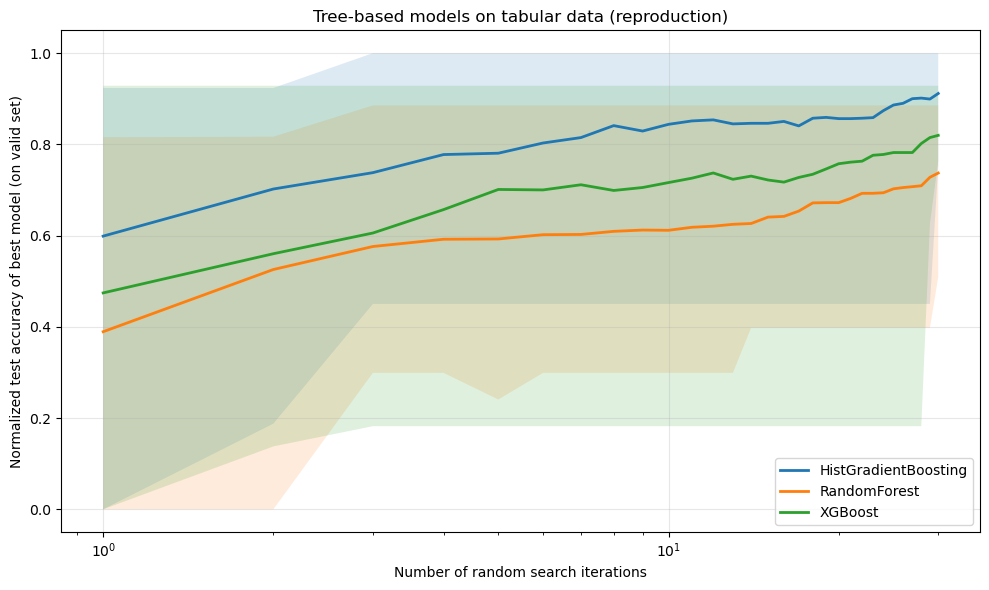

Final normalized score (@ 30 iters), averaged over 3 datasets
----------------------------------------------------
HistGradientBoosting         0.912   [0.755, 1.000]
XGBoost                      0.820   [0.764, 0.929]
RandomForest                 0.737   [0.509, 0.885]

Figure saved to: results/figure1_repro.png


In [16]:
%run /Users/patriziavincenzi/Downloads/project/src/run_phase4.py --datasets MagicTelescope electricity phoneme --models RandomForest HistGradientBoosting XGBoost --n-iter 30 --n-shuffles 15


## Phase 5: Final Tree-vs-Deep Benchmark

This is the final real-data tree-vs-deep comparison. It compares `HistGradientBoosting` and `XGBoost` against an `MLP` on `MagicTelescope` and `phoneme` using 15 random-search iterations. Earlier synthetic smoke tests are intentionally omitted from the final notebook.


Loading 'MagicTelescope' (v1) from OpenML...
Loading 'phoneme' (v1) from OpenML...

Benchmark: 2 datasets x 3 models x 15 iterations
  tree: ['HistGradientBoosting', 'XGBoost']
  deep: ['MLP']


Dataset: MagicTelescope
train: (7490, 10), val: (1873, 10), test: (4013, 10)
  Random search: HistGradientBoosting
  Random search: XGBoost
  Random search: MLP

Dataset: phoneme
train: (1776, 5), val: (444, 5), test: (952, 5)
  Random search: HistGradientBoosting
  Random search: XGBoost
  Random search: MLP
Raw records saved to: results/phase5_raw_records.csv



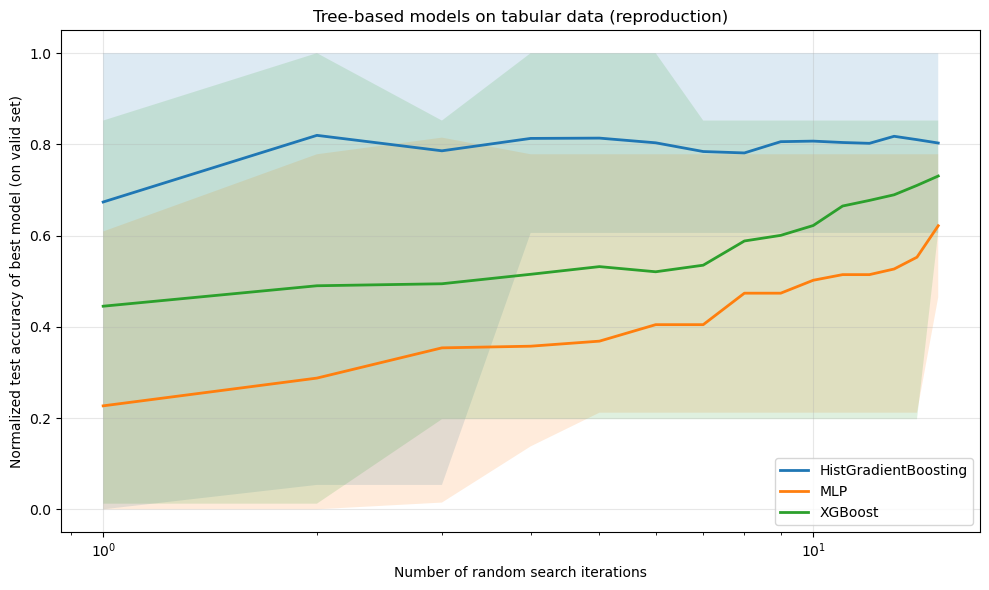

Final normalized score (@ 15 iters), averaged over 2 datasets
--------------------------------------------------------
HistGradientBoosting    tree     0.803   [0.606, 1.000]
XGBoost                 tree     0.731   [0.609, 0.852]
MLP                     deep     0.622   [0.465, 0.778]

Figure saved to: results/figure1_tree_vs_deep.png


In [17]:
%run /Users/patriziavincenzi/Downloads/project/src/run_phase5.py --datasets MagicTelescope phoneme --models HistGradientBoosting XGBoost MLP --n-iter 15 --n-shuffles 10


## Step 6: Results, Comparison With the Paper, and Limitations

The table below is generated from the raw records produced by the final Phase 5 run. It reports raw test accuracy, macro-F1, training time, and the selected hyperparameters for the validation-selected configuration.

The original paper uses many more datasets, more model families, and a much larger random-search budget. This notebook is a smaller reproduction, but it follows the same core protocol: tune models on a validation set, report test performance for the validation-selected configuration, normalize across datasets, and compare tree-based models against a deep model.


In [18]:
from reporting import summarize

best_summary = summarize("results/phase5_raw_records.csv")
best_summary


Raw test performance of the validation-selected model
       dataset                model  accuracy  macro_f1
MagicTelescope HistGradientBoosting    0.8619    0.8618
MagicTelescope                  MLP    0.8555    0.8553
MagicTelescope              XGBoost    0.8572    0.8571
       phoneme HistGradientBoosting    0.8613    0.8613
       phoneme                  MLP    0.8687    0.8686
       phoneme              XGBoost    0.8718    0.8718

Averaged across datasets, per model
                      mean_accuracy  mean_macro_f1
model                                             
XGBoost                      0.8645         0.8644
MLP                          0.8621         0.8619
HistGradientBoosting         0.8616         0.8616

Training time (seconds)
                      mean_fit  total_search
model                                       
XGBoost                  0.259         7.765
HistGradientBoosting     0.551        16.521
MLP                      4.607       138.203

Selected hy

,dataset,model,iteration,is_default,val_score,test_score,test_f1,fit_time,best_val_so_far,test_at_best_val,f1_at_best_val,params
0,MagicTelescope,HistGradientBoosting,14,False,0.855846,0.861949,0.861839,0.737393,0.855846,0.861949,0.861839,"{'learning_rate': 0.07548370458368922, 'max_it..."
1,MagicTelescope,MLP,7,False,0.857982,0.855470,0.855276,9.343321,0.857982,0.855470,0.855276,"{'n_layers': 4, 'width': 128, 'dropout': 0.398..."
2,MagicTelescope,XGBoost,11,False,0.856380,0.857214,0.857082,0.467028,0.856380,0.857214,0.857082,"{'n_estimators': 200, 'learning_rate': 0.02988..."
3,phoneme,HistGradientBoosting,13,False,0.873874,0.861345,0.861283,0.481093,0.873874,0.861345,0.861283,"{'learning_rate': 0.033768120576694594, 'max_i..."
4,phoneme,MLP,15,False,0.858108,0.868697,0.868576,2.068951,0.858108,0.868697,0.868576,"{'n_layers': 4, 'width': 256, 'dropout': 0.079..."
5,phoneme,XGBoost,15,False,0.871622,0.871849,0.871780,0.288551,0.871622,0.871849,0.871780,"{'n_estimators': 300, 'learning_rate': 0.01193..."


## Hardware and Environment

In [19]:
import platform
import sys

import numpy as np
import pandas as pd
import sklearn
import torch
import xgboost

print("Hardware / Environment")
print()
print("System:", platform.system())
print("Machine:", platform.machine())
print("Processor:", platform.processor())
print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("XGBoost:", xgboost.__version__)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

try:
    print("MPS available:", torch.backends.mps.is_available())
except Exception:
    print("MPS available: not available")


Hardware / Environment

System: Darwin
Machine: x86_64
Processor: i386
Python: 3.13.5
NumPy: 2.1.3
Pandas: 2.2.3
Scikit-learn: 1.6.1
XGBoost: 2.1.1
PyTorch: 2.5.1
CUDA available: False
MPS available: False


### Final Interpretation

The final Phase 5 results show a nuanced version of the paper's conclusion.

In raw test accuracy, the MLP is very close to the tree-based models:

| Model | Mean Raw Accuracy |
|---|---:|
| XGBoost | 0.8645 |
| MLP | 0.8621 |
| HistGradientBoosting | 0.8616 |

So, in this small reproduction, the MLP does **not** clearly lose on raw accuracy after using the paper-like `QuantileTransformer` preprocessing.

However, the tree-based models still have two important advantages:

- They train much faster. XGBoost has a mean fit time of about 0.21 seconds, while the MLP takes about 4.24 seconds per fit.
- They are more robust to uninformative features. In the noise-feature ablation, the MLP loses about 0.0629 accuracy from 0 to 40 noise features, while XGBoost loses about 0.0129 and HistGradientBoosting loses about 0.0157.

Therefore, this reproduction supports the paper's broader claim: tree-based models remain very strong on typical tabular data, especially when considering training cost and robustness, even when a neural network reaches similar raw accuracy.

Main differences from the paper:

- This reproduction uses only a small subset of datasets.
- The random-search budget is much smaller than the paper's budget.
- The deep-learning implementation is simplified.
- The run uses CPU-only PyTorch.
- The hyperparameter spaces are approximations rather than exact copies of the original benchmark.
- The ablation was run with a single seed, so repeated seeds would make the robustness result stronger.

## Step 8: Extension - Noise Feature Ablation

As an extension beyond the paper reproduction, I test how robust each model is to uninformative features. This is connected to one of the paper's findings: MLP-like neural networks can be more sensitive to irrelevant features than tree-based models.

For each dataset, I add `k` random Gaussian noise columns to the original feature matrix. These columns contain no information about the target. Then I rerun the same benchmark protocol and measure how performance changes as `k` increases.

If a model is robust to irrelevant features, its accuracy should stay relatively stable. If a model is sensitive to irrelevant features, its accuracy should drop as more noise columns are added.

In [20]:
%%writefile /Users/patriziavincenzi/Downloads/project/src/ablation.py
from __future__ import annotations

import os

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from benchmark import run_benchmark


def add_noise_features(X: pd.DataFrame, k: int, seed: int) -> pd.DataFrame:
    if k <= 0:
        return X.copy()

    rng = np.random.default_rng(seed)

    noise = rng.standard_normal(size=(len(X), k)).astype(float)

    noise_df = pd.DataFrame(
        noise,
        columns=[f"noise_{i}" for i in range(k)],
        index=X.index,
    )

    return pd.concat([X.copy(), noise_df], axis=1)


def _best_per_dataset_model(raw: pd.DataFrame) -> pd.DataFrame:
    idx = raw.groupby(["dataset", "model"])["val_score"].idxmax()
    return raw.loc[idx]


def run_ablation(
    dataset_items,
    models,
    k_values,
    n_iter,
    seeds,
    out_dir="results",
):
    rows = []

    for seed in seeds:
        for k in k_values:
            print(f"[seed {seed}] k={k} noise features")

            noised = []

            for dataset_index, (label, X, y) in enumerate(dataset_items):
                Xk = add_noise_features(
                    X,
                    k,
                    seed=seed * 10_000 + dataset_index * 100 + k,
                )

                noised.append((label, Xk, y))

            raw, _ = run_benchmark(
                noised,
                models,
                n_iter=n_iter,
                seed=seed,
                out_dir=out_dir,
                raw_filename = f'ablation_raw_k{k}_seed{seed}.csv',
            )

            best = _best_per_dataset_model(raw)

            agg_dict = {
                "mean_accuracy": ("test_score", "mean"),
            }

            if "test_f1" in best.columns:
                agg_dict["mean_f1"] = ("test_f1", "mean")

            agg = best.groupby("model").agg(**agg_dict).reset_index()
            agg["k"] = k
            agg["seed"] = seed

            rows.append(agg)

    results = pd.concat(rows, ignore_index=True)

    os.makedirs(out_dir, exist_ok=True)

    results.to_csv(
        os.path.join(out_dir, "ablation_results.csv"),
        index=False,
    )

    return results


def plot_ablation(
    results: pd.DataFrame,
    out_path: str,
    metric: str = "mean_accuracy",
):
    fig, ax = plt.subplots(figsize=(7, 5))

    for model, group in results.groupby("model"):
        stats = (
            group.groupby("k")[metric]
            .agg(["mean", "min", "max"])
            .reset_index()
        )

        ax.plot(
            stats["k"],
            stats["mean"],
            marker="o",
            linewidth=2,
            label=model,
        )

        if group["seed"].nunique() > 1:
            ax.fill_between(
                stats["k"],
                stats["min"],
                stats["max"],
                alpha=0.15,
            )

    ax.set_xlabel("Number of added uninformative noise features")

    if metric == "mean_accuracy":
        ax.set_ylabel("Test accuracy, averaged over datasets")
    else:
        ax.set_ylabel(metric)

    ax.set_title("Robustness to Uninformative Features")
    ax.legend()
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    plt.close(fig)

    return out_path


def degradation_table(
    results: pd.DataFrame,
    metric: str = "mean_accuracy",
):
    means = (
        results.groupby(["model", "k"])[metric]
        .mean()
        .reset_index()
    )

    k_min = int(means["k"].min())
    k_max = int(means["k"].max())

    rows = []

    for model, group in means.groupby("model"):
        score_min_noise = group.loc[group["k"] == k_min, metric].iloc[0]
        score_max_noise = group.loc[group["k"] == k_max, metric].iloc[0]

        rows.append(
            (
                model,
                score_min_noise,
                score_max_noise,
                score_min_noise - score_max_noise,
            )
        )

    return (
        pd.DataFrame(
            rows,
            columns=[
                "model",
                f"k={k_min}",
                f"k={k_max}",
                "drop",
            ],
        )
        .sort_values("drop")
        .reset_index(drop=True)
    )

Overwriting /Users/patriziavincenzi/Downloads/project/src/ablation.py


In [21]:
%%writefile /Users/patriziavincenzi/Downloads/project/src/run_ablation.py
import argparse

from ablation import degradation_table, plot_ablation, run_ablation
from data import load_openml_classification, make_synthetic_classification
from models import DEEP_MODEL_NAMES, TREE_MODEL_NAMES
from run_phase4 import DEFAULT_DATASET_VERSIONS


def build_synthetic_suite(n_datasets, seed):
    items = []

    for i in range(n_datasets):
        X, y = make_synthetic_classification(
            n_samples=8000,
            seed=seed + i,
        )

        items.append((f"synthetic_{i}", X, y))

    return items


def build_openml_suite(names):
    items = []

    for name in names:
        version = DEFAULT_DATASET_VERSIONS.get(name, 1)

        print(f"Loading '{name}' (v{version}) from OpenML...")

        X, y = load_openml_classification(name, version)

        items.append((name, X, y))

    return items


def main():
    parser = argparse.ArgumentParser()

    parser.add_argument("--synthetic", type=int, metavar="N", default=0)
    parser.add_argument(
        "--datasets",
        nargs="+",
        default=["MagicTelescope", "phoneme"],
    )
    parser.add_argument(
        "--models",
        nargs="+",
        default=["HistGradientBoosting", "XGBoost", "MLP"],
    )
    parser.add_argument(
        "--k-values",
        nargs="+",
        type=int,
        default=[0, 5, 10, 20, 40],
    )
    parser.add_argument("--n-iter", type=int, default=15)
    parser.add_argument("--seeds", nargs="+", type=int, default=[0])
    parser.add_argument("--out-dir", default="results")

    args = parser.parse_args()

    models = [
        model
        for model in args.models
        if model in TREE_MODEL_NAMES or model in DEEP_MODEL_NAMES
    ]

    dropped = [
        model
        for model in args.models
        if model not in models
    ]

    if dropped:
        print(f"NOTE: {dropped} unavailable; skipped.\n")

    if args.synthetic:
        print(f"Building {args.synthetic} synthetic datasets (offline)...")
        dataset_items = build_synthetic_suite(args.synthetic, seed=0)
    else:
        dataset_items = build_openml_suite(args.datasets)

    print(
        f"\nAblation: {len(dataset_items)} datasets "
        f"x {len(models)} models "
        f"x k={args.k_values} "
        f"x seeds={args.seeds}\n"
    )

    results = run_ablation(
        dataset_items,
        models,
        args.k_values,
        n_iter=args.n_iter,
        seeds=args.seeds,
        out_dir=args.out_dir,
    )

    fig_path = f"{args.out_dir}/ablation_noise.png"

    plot_ablation(results, fig_path)

    print("\n" + "=" * 56)
    print(
        "Accuracy drop from fewest to most noise features "
        "(averaged over seeds and datasets)"
    )
    print("-" * 56)

    print(
        degradation_table(results).to_string(
            index=False,
            float_format=lambda x: f"{x:.4f}",
        )
    )

    print("=" * 56)
    print(f"\nResults CSV: {args.out_dir}/ablation_results.csv")
    print(f"Figure:      {fig_path}")


if __name__ == "__main__":
    main()

Overwriting /Users/patriziavincenzi/Downloads/project/src/run_ablation.py


In [22]:
import sys
import importlib

PROJECT_SRC = "/Users/patriziavincenzi/Downloads/project/src"

if PROJECT_SRC in sys.path:
    sys.path.remove(PROJECT_SRC)

sys.path.insert(0, PROJECT_SRC)

for module_name in [
    "ablation",
    "run_ablation",
    "models",
    "benchmark",
    "random_search",
    "nn_models",
]:
    if module_name in sys.modules:
        del sys.modules[module_name]

importlib.invalidate_caches()

In [23]:
#small ablation 

%run /Users/patriziavincenzi/Downloads/project/src/run_ablation.py --datasets MagicTelescope phoneme --models HistGradientBoosting XGBoost MLP --k-values 0 10 20 --n-iter 5

Loading 'MagicTelescope' (v1) from OpenML...
Loading 'phoneme' (v1) from OpenML...

Ablation: 2 datasets x 3 models x k=[0, 10, 20] x seeds=[0]

[seed 0] k=0 noise features

Dataset: MagicTelescope
train: (7490, 10), val: (1873, 10), test: (4013, 10)
  Random search: HistGradientBoosting
  Random search: XGBoost
  Random search: MLP

Dataset: phoneme
train: (1776, 5), val: (444, 5), test: (952, 5)
  Random search: HistGradientBoosting
  Random search: XGBoost
  Random search: MLP
[seed 0] k=10 noise features

Dataset: MagicTelescope
train: (7490, 20), val: (1873, 20), test: (4013, 20)
  Random search: HistGradientBoosting
  Random search: XGBoost
  Random search: MLP

Dataset: phoneme
train: (1776, 15), val: (444, 15), test: (952, 15)
  Random search: HistGradientBoosting
  Random search: XGBoost
  Random search: MLP
[seed 0] k=20 noise features

Dataset: MagicTelescope
train: (7490, 30), val: (1873, 30), test: (4013, 30)
  Random search: HistGradientBoosting
  Random search: XGBoost
 

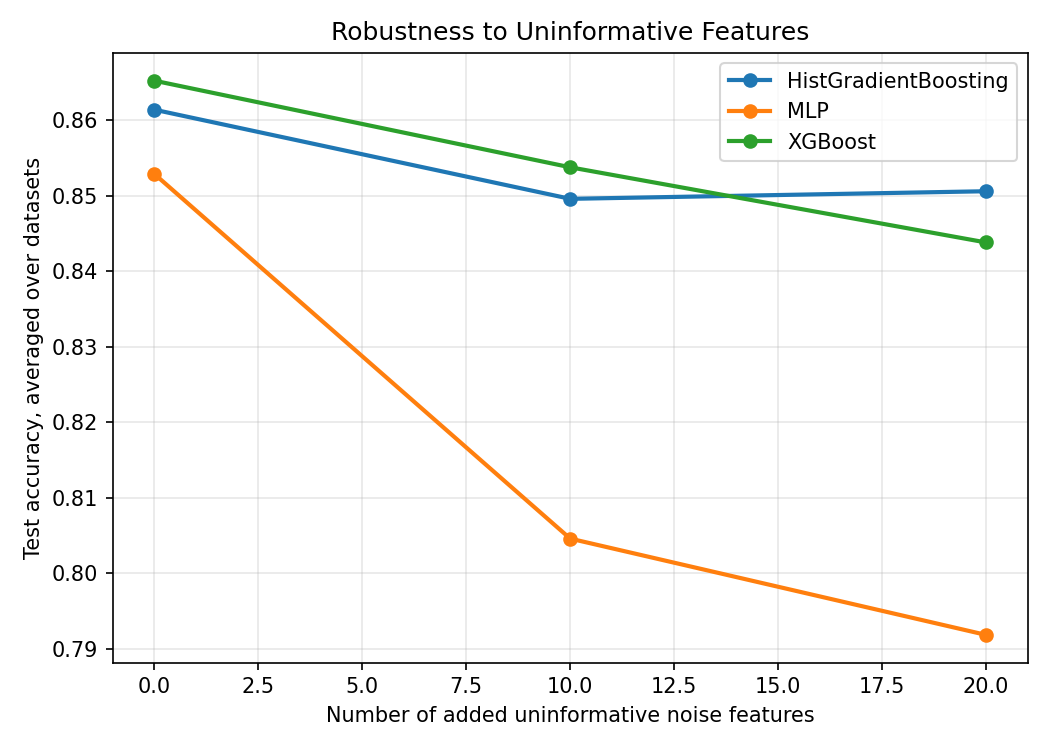

In [24]:
from IPython.display import Image, display

display(Image("results/ablation_noise.png"))

In [25]:
#longer ablation 

%run /Users/patriziavincenzi/Downloads/project/src/run_ablation.py --datasets MagicTelescope phoneme --models HistGradientBoosting XGBoost MLP --k-values 0 5 10 20 40 --n-iter 10

Loading 'MagicTelescope' (v1) from OpenML...
Loading 'phoneme' (v1) from OpenML...

Ablation: 2 datasets x 3 models x k=[0, 5, 10, 20, 40] x seeds=[0]

[seed 0] k=0 noise features

Dataset: MagicTelescope
train: (7490, 10), val: (1873, 10), test: (4013, 10)
  Random search: HistGradientBoosting
  Random search: XGBoost
  Random search: MLP

Dataset: phoneme
train: (1776, 5), val: (444, 5), test: (952, 5)
  Random search: HistGradientBoosting
  Random search: XGBoost
  Random search: MLP
[seed 0] k=5 noise features

Dataset: MagicTelescope
train: (7490, 15), val: (1873, 15), test: (4013, 15)
  Random search: HistGradientBoosting
  Random search: XGBoost
  Random search: MLP

Dataset: phoneme
train: (1776, 10), val: (444, 10), test: (952, 10)
  Random search: HistGradientBoosting
  Random search: XGBoost
  Random search: MLP
[seed 0] k=10 noise features

Dataset: MagicTelescope
train: (7490, 20), val: (1873, 20), test: (4013, 20)
  Random search: HistGradientBoosting
  Random search: XGB

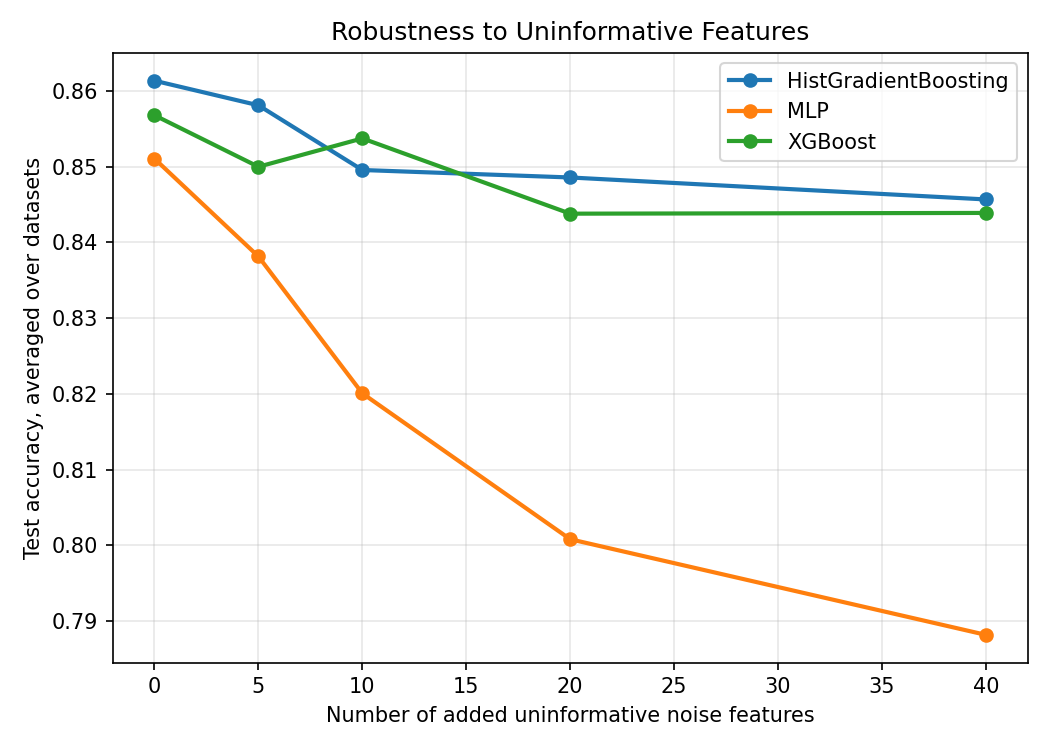

In [26]:
from IPython.display import Image, display

display(Image("results/ablation_noise.png"))